<a href="https://colab.research.google.com/github/sejuti009/Welcome-To-Data-Science-/blob/main/tutorial_week05_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# COMP3670 / COMP6670 - Introduction to Machine Learning
# Tutorials Weeks 5 and 6: a complete machine learning pipeline

**The Australian National University, School of Computing. Semester 2, 2026.**

Convener: Dr. Diego Marcondes.

---

For four weeks this course has been about ideas: hypothesis sets, the in-sample
error `Ein`, the out-of-sample error `Eout`, Hoeffding's inequality, the VC
dimension, and a catalogue of models. All of it on paper. In Weeks 5 and 6 tutorials we will see how it applies in practice, on real
data, in Python. This week is Part A: working out how the data behaves. Next week we fit the models.

## 1. The data: a decade of filling up the tank

Every single time Diego has filled up the tank of one of his cars, since June 2015,
he has collected some data: the date, how far he had driven since the last fill-up and
how many litres went in.

**He has been doing this for more than ten years just so he could have real data to deliver this tutorial to you!**

The log follows seven cars. Here they are.

<table><tr><td align="center" valign="top">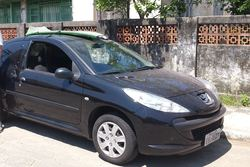<br><b>Peugeot 207</b><br><span style="font-size:90%">small hatchback</span></td><td align="center" valign="top">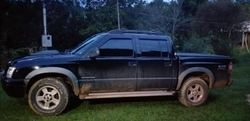<br><b>Chevrolet S10</b><br><span style="font-size:90%">pickup</span></td><td align="center" valign="top">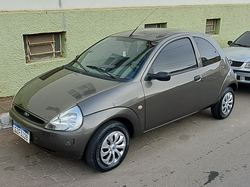<br><b>Ford Ka</b><br><span style="font-size:90%">small hatchback</span></td></tr></table>

<table><tr><td align="center" valign="top">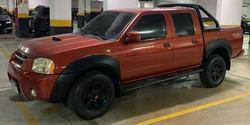<br><b>Nissan Frontier</b><br><span style="font-size:90%">pickup, diesel</span></td><td align="center" valign="top">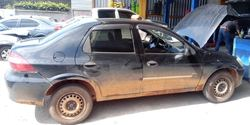<br><b>Chevrolet Prisma</b><br><span style="font-size:90%">small sedan</span></td></tr></table>

<table><tr><td align="center" valign="top">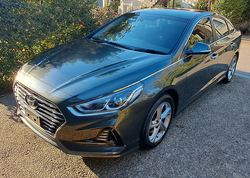<br><b>Hyundai Sonata</b><br><span style="font-size:90%">large sedan</span></td><td align="center" valign="top">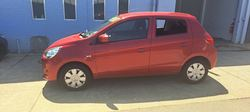<br><b>Mitsubishi Mirage</b><br><span style="font-size:90%">small hatchback</span></td></tr></table>

### What is in the file

The dataset is available **[here](https://www.dropbox.com/scl/fi/xi0uwdi8m7rvduk8zxwbc/vehicle_fuel_log.csv?rlkey=iz294cf1tzgdmmru7o9txxoka&dl=0)**. It comes with a **[README file](https://www.dropbox.com/scl/fi/sf45rfkzj9jayc1l50bqs/README.txt?rlkey=vlfp97on8ieov8oxdedbbmz13&st=y6dpfsu6&dl=0)**,
and reading it is the first thing you should do with any dataset somebody hands
you. Click on the link and see what it tells you. Then click on the dataset link
to see how it is organised.

Each row of the dataset is **one tank of fuel**. The columns are:

| Column | Meaning | Type |
|---|---|---|
| `vehicle` | which of the seven cars | categorical, 7 categories |
| `month` | the month of the fill-up, for example `2022-01` | categorical, ordered |
| `km_on_tank` | kilometres driven on that tank, since the previous fill-up | continuous |
| `litres` | litres of fuel put in | continuous |
| `efficiency` | fuel efficiency of that tank, in km per litre | continuous |
| `driving_condition` | `City`, `Highway` or `Mixed` | categorical, 3 categories, **often missing** |

Three things are worth knowing before you touch the data. This is what Lecture 3
calls **prior information**: everything you know about the problem before you
start fitting anything. It is not a formality. It decides which models are
sensible, which comparisons are fair, and which apparent discoveries are
artefacts.

**First, `efficiency` is not a new measurement.** It is computed:

    efficiency = km_on_tank / litres

Any two of those three columns determine the third. Keep that in mind when you
start choosing which columns to use as features.

**Second, `driving_condition` is missing a lot.** It was only ever written down
for the Sonata, the Mirage, the Prisma and the Frontier. For the Ford Ka, the S10
and the Peugeot 207 it was never recorded at all.

**Third, the cars are not the same kind of machine.** If you know nothing about
cars, this is the background you need, and it is genuine prior information: it
tells you what the data *should* look like before you plot anything.

- **How much fuel a car uses depends mostly on how heavy it is and how big its
  engine is.** A heavy vehicle with a large engine has to burn more fuel to move
  the same distance. So the ordering of these cars by fuel use is largely
  predictable from their size.
- The **Ford Ka**, **Mirage**, **Peugeot 207** and **Prisma** are small, light
  cars with small engines, built for city driving and cheap running. Expect them
  to travel the furthest on a litre.
- The **Sonata** is a large sedan: heavier, bigger engine, more comfortable.
  Expect it to sit somewhere in the middle.
- The **S10** and the **Frontier** are **pickup trucks**: heavy, tall, boxy, with
  large engines built for towing and carrying loads. Expect them to use the most
  fuel. The Frontier runs on **diesel**, which extracts more energy per litre
  than petrol, so a diesel usually travels further on a litre than a petrol
  vehicle of the same size.
- **Driving on the highway uses less fuel per kilometre than driving in the
  city.** In the city you constantly accelerate, brake and idle at lights, and
  every acceleration costs fuel that braking then throws away. On a highway the
  car holds a steady speed and wastes far less.

So before seeing a single number you should already expect: pickups worst, small
cars best, highway better than city for every car. Part of the value of the
descriptive analysis is checking whether the data is consistent with this prior information.

## 2. The tools

Python on its own is a fairly small language. Almost everything useful lives in
**packages** that you load at the start of your program. We need four.

| Package | What it is for | Conventional short name |
|---|---|---|
| `numpy` | arrays of numbers, and fast arithmetic on them | `np` |
| `pandas` | tables of data with named columns | `pd` |
| `matplotlib` | plots | `plt` |
| `scikit-learn` | machine learning models | imported piece by piece |

The line `import numpy as np` means "load the package `numpy`, and from now on let
me write `np` instead of `numpy`".

In [ ]:
# This cell makes sure every package the notebook needs is installed, then
# loads them. Run this cell first, every time you open the notebook. It
# should print Packages loaded at the end.

import importlib   # lets us test if a package is installed without loading it
import subprocess  # lets us run a command, here pip install, from inside Python
import sys         # sys.executable is the path to the Python running this notebook

# A dictionary: the name you import -> the name you pip install. Most
# packages use the same name for both, but scikit-learn is the exception:
# you import it as sklearn but you pip install it as scikit-learn.
required = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "sklearn": "scikit-learn",
}

# Go through each package one at a time.
for import_name, pip_name in required.items():
    # Try to find the package without fully loading it yet.
    try:
        importlib.import_module(import_name)
    # If it is not installed, Python raises ImportError here.
    except ImportError:
        print("Installing", pip_name, "...")
        # Run: python -m pip install <package>, using the same Python that is
        # running this notebook.
        subprocess.check_call([sys.executable, "-m", "pip", "install", pip_name])

# Now that every package is guaranteed to be present, load them as normal.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Make the plots a sensible size and reasonably readable.
plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["font.size"] = 11

print("Packages loaded.") #This function prints something in the console


### A Python primer

A **variable** is a name for a value. A **list** is an ordered collection written
with square brackets. Counting indices starts at **zero** in Python.

In [ ]:
# A variable is just a name attached to a value.
distance = 412.5          # a decimal number, called a "float"
tanks = 7                 # a whole number, called an "int"
name = "Frontier"         # text, called a "string"

print(distance, tanks, name)

# A list holds several values in order. Square brackets.
efficiencies = [10.4, 13.9, 15.2, 11.1]

# Positions count from ZERO. So the first element is at position 0.
print("first  :", efficiencies[0])
print("second :", efficiencies[1])
print("last   :", efficiencies[-1])     # -1 means "last", -2 means "second last"

# A "slice" takes a range of positions. The start is included, the stop is NOT.
print("first two:", efficiencies[0:2])

print("how many :", len(efficiencies)) #Length of a list

In [ ]:
# A numpy ARRAY looks like a list, but arithmetic works on the whole thing
# at once. This is the single most important object in numpy.

x = np.array([10.4, 13.9, 15.2, 11.1])

print("the array      :", x)
print("add 1 to all   :", x + 1)          # no loop needed
print("double them all:", x * 2)
print("mean           :", x.mean())
print("std deviation  :", x.std())
print("largest        :", x.max())

# You can compare a whole array to a number. The result is an array of
# True/False, which numpy calls a "mask".
mask = x > 12
print() #Jump a line
print("which are above 12 :", mask)

# And you can use a mask to pull out just those elements. This is how you will
# filter data.
print("the values above 12:", x[mask])
print("how many above 12  :", mask.sum())   # True counts as 1, False as 0

## 3. Reading the data

The dataset lives online as a `.csv` file, which is the plainest possible way to
store a table: one line per row, values separated by commas. `pandas` reads it in
one line, straight from a web address.

A **DataFrame** is the pandas version of a spreadsheet: a table where every
column has a name and a type. That is what our dataset will be. You pull a single
column out with square brackets and its name, and what comes back behaves very
much like a numpy array.

In [ ]:
# The address of the dataset. If you are running this offline, replace the
# address with the path to your local copy, for example "vehicle_fuel_log.csv".

DATA_URL = ("https://www.dropbox.com/scl/fi/xi0uwdi8m7rvduk8zxwbc/"
            "vehicle_fuel_log.csv?rlkey=iz294cf1tzgdmmru7o9txxoka&dl=1")

# read_csv does exactly what it says: it reads a csv file and hands back a
# DataFrame, which is a table with named columns.
data = pd.read_csv(DATA_URL)

# .shape reports (number of rows, number of columns).
print("rows and columns:", data.shape)

In [ ]:
# .head(n) shows the first n rows. Always look at your data before anything else.
data.head(8)

In [ ]:
# .info() lists the columns, what type each one holds, and how many values are
# actually present. Look at the "non-null" count for driving_condition.
data.info()

In [ ]:
#Pull the vehicle column
data['vehicle']

> ### Discuss
>
> **Q3.1** The rows are in no particular order, and the exact dates have been
> replaced by the month. Both were done deliberately. What could go wrong if
> the rows had been left in chronological order and you had split off a test
> sample by taking the last 20 percent of the file?

## 4. Before anything else: lock away a test sample

Stop. We have looked at eight rows and the column types, and that is all we are
allowed to see until we have done this.

Remember:

> **The test set may be used exactly once, at the end.**

The error of a hypothesis measured on data that played **no part
whatsoever** in producing that hypothesis is an honest estimate of `Eout`. Plain
Hoeffding applies to it: no VC dimension, no union bound, just the size of the
test sample.

The moment the test data influences anything at all, that guarantee is gone. And
"influences anything" is much broader than one might expect. It includes:

- fitting a model on it, obviously,
- choosing a bandwidth or a polynomial degree by looking at the error on it,
- deciding which features to use after seeing a plot that included it,
- deciding to drop an outlier you noticed in it,
- *looking at a histogram of it and forming an opinion.*

Be aware: **YOU** are part of the learning algorithm. Anything you see, you cannot unsee, and every decision
you make afterwards is contaminated by it.

So we split now, write the test sample to a file, and delete it from memory. We
will not load it again until the very end.

In [ ]:
# train_test_split is scikit-learn's tool for splitting a dataset at random.
from sklearn.model_selection import train_test_split

# Two choices worth understanding:
#
# test_size=0.2   hold out 20 percent, which is an 80/20 split for training and test.
#
# random_state=42 fixes the random number generator, so that everybody in the
#                 room gets exactly the same split and can compare numbers. Furthermore,
#                 this makes your experiment reproducible.
#
# stratify=data["vehicle"]
#                 splits each car separately, so that all seven cars appear in
#                 both halves in the same proportions. Without it, the Ford Ka
#                 has only 11 rows in total and could land almost entirely on one
#                 side of the split by bad luck.

train_data, test_data = train_test_split(
    data,
    test_size=0.2,
    random_state=42,
    stratify=data["vehicle"],
)

print("training rows:", len(train_data))
print("test rows    :", len(test_data))

In [ ]:
# Write the test sample to a file, then remove it from memory.
#
# The "del" statement deletes a variable. After this cell, the name test_data
# does not exist any more, and any attempt to use it is an error. That is on
# purpose: it makes peeking take a deliberate act rather than a careless one (oops, saw the test data by mistake).

test_data.to_csv("test_sample.csv", index=False)
print("Test sample written to test_sample.csv and closed.")

del test_data

# From here on, "train_data" is the only data we have. Give it a shorter name.
df = train_data.copy() #df is short for DataFrame
print("Working from now on with", len(df), "rows.")

> ### Discuss
>
> **Q4.1** We used `stratify` so that every car appears in both halves. Is that
> cheating? We used the `vehicle` column of the test rows to decide the split.
>
> **Q4.2** Our test sample has 44 rows. Lecture 3 gave the error bar for a test
> estimate as depending only on the number of test points. Suppose we had held out
> 50 percent instead of 20 percent. What would we gain, and what would we lose?

## 5. Looking at one variable at a time

Now the part that most people skip and should not: before any model,
find out how the data actually behaves.

We start with the **categorical** variables. For those, "how it behaves" means
counting frequencies.

In [ ]:
# value_counts() counts how often each category appears in a column.
print("Fill-ups per car")

# df["vehicle"] pulls out one column; .value_counts() counts each distinct value.
print(df["vehicle"].value_counts())

print()   # print() with nothing inside just leaves a blank line

print("Fill-ups per driving condition")

# dropna=False tells pandas to also COUNT the missing values, instead of
# silently ignoring them.
print(df["driving_condition"].value_counts(dropna=False))

Note `dropna=False` in the second count: it makes pandas report the missing
values instead of quietly ignoring them.

Now the **continuous** variables. For those, "how it behaves" means centre, spread
and shape.

In [ ]:
# Pick the three numeric columns. Note the DOUBLE square brackets: the inner
# brackets make a list of column names, the outer ones do the selecting.
numeric = df[["km_on_tank", "litres", "efficiency"]]

# .describe() gives the standard summary of every numeric column at once:
# how many values, the mean, the standard deviation, the smallest, the three
# quartiles, and the largest.
# .round(2) cuts the printing down to two decimal places so it is readable.
numeric.describe().round(2)

### The shape of a distribution: histograms

A summary of centre and spread hides the shape. A histogram shows it: chop the
range into bins, count how many observations fall in each.

The number of bins is a choice, and it matters.

In [ ]:
# We want the same picture for all three numeric variables, at three different
# bin counts. That is 3 x 3 = 9 plots, so we build a grid with 3 rows and
# 3 columns and fill it in with two loops.

variables = ["km_on_tank", "litres", "efficiency"]   # one per ROW of the grid
bin_counts = [5, 15, 60]                             # one per COLUMN of the grid

# plt.subplots(rows, columns) creates the grid. It hands back the whole figure
# and an array of "axes", one per small plot. axes[i][j] is row i, column j.
fig, axes = plt.subplots(3, 3, figsize=(14, 10))

# enumerate() gives us the position AND the value, so row_index counts 0, 1, 2.
for row_index, variable in enumerate(variables):
    for column_index, bins in enumerate(bin_counts):

        # Select the small plot in this row and column.
        ax = axes[row_index][column_index]

        # .hist() draws the histogram: it chops the range of the variable into
        # "bins" equal intervals and counts how many observations land in each.
        ax.hist(df[variable], bins=bins, color="steelblue", edgecolor="white")

        # A title on each small plot so we can tell them apart.
        ax.set_title("%s, %d bins" % (variable, bins))

    # Label the vertical axis once per row, on the leftmost plot only.
    axes[row_index][0].set_ylabel("count")

# tight_layout() stops the titles and labels from overlapping each other.
plt.tight_layout()

# show() actually draws the figure.
plt.show()

Nine pictures, three variables, and the same lesson in every row.

Read across the **efficiency** row first, because it is the clearest.

- With **5 bins** you see a single lump. The picture says "efficiency is somewhere
  between 6 and 24, mostly in the middle", and nothing more. Real structure has
  been averaged away.
- With **60 bins** the picture falls apart into a row of thin spikes with gaps
  between them, most bars holding one or two tanks. The gaps are not real: there
  is no reason a car cannot achieve an efficiency that happens to fall in an empty
  bin. You are looking at the noise of which particular 173 tanks we happened to
  record.
- With **15 bins** you see the useful picture, and the important thing about it is
  that it is **not a single lump**. There is a small group stranded down at the
  bottom, below 8, then a crowded region running from about 10 to 17, and a thin
  tail reaching out to nearly 24.

The other two rows describe the tanks themselves. `km_on_tank` runs from under 100
km to more than 900, with most tanks between 300 and 500. `litres` is visibly
lumpy at 15 bins rather than smooth, which is worth remembering: the cars have
very different tank sizes, so the lumps are the cars showing through.

The number of bins is a **complexity parameter**. Too few and you erase the
structure; too many and you draw the noise.

### Kernel density estimation, and the bandwidth `sigma`

A histogram is jumpy, and it depends on exactly where you put the bin edges.
Lecture 4 introduced the smoother alternative: put a small bump, a **kernel**, on
top of every observation, and add them up. The width of those bumps is the
**bandwidth**, written `sigma`.

`sigma` is the complexity knob:

- **small `sigma`** means narrow bumps, so each observation keeps to itself. The
  estimate is spiky. This is **overfitting**.
- **large `sigma`** means wide bumps that overlap heavily and blur into one another.
  The estimate is a featureless hill. This is **underfitting**.

The next cell has `sigma` at the top. **Run it several times with different
values.** See what happens.

In [ ]:
from sklearn.neighbors import KernelDensity

# ---------------------------------------------------------------------------
# CHANGE THIS AND RUN THE CELL AGAIN. Try 0.05, then 0.2, then 0.5, then 1.0.
sigma = 0.05
# ---------------------------------------------------------------------------

# The same three variables as before, one plot each, side by side.
variables = ["km_on_tank", "litres", "efficiency"]

# A grid with 1 row and 3 columns.
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, variable in zip(axes, variables):

    # .values turns the pandas column into a plain numpy array.
    values = df[variable].values

    # Each variable lives on a completely different scale: kilometres run into
    # the hundreds, efficiency is around 10. A bandwidth of 0.5 means something
    # quite different for each. So we measure sigma in STANDARD DEVIATIONS of
    # the variable, which makes one setting of sigma comparable across the three.
    bandwidth = sigma * values.std()

    # KernelDensity wants the data as a column, not a row, hence the reshape.
    # reshape(-1, 1) means "one column, work out the number of rows yourself".
    column = values.reshape(-1, 1)

    # Build the estimator. kernel="gaussian" puts a normal-shaped bump on every
    # observation, and bandwidth is how wide each bump is.
    kde = KernelDensity(bandwidth=bandwidth, kernel="gaussian")

    # .fit() hands the data to the estimator.
    kde.fit(column)

    # To draw a curve we need to evaluate the estimate at many points.
    # np.linspace(a, b, n) makes n equally spaced numbers from a to b.
    grid = np.linspace(values.min(), values.max(), 400).reshape(-1, 1)

    # score_samples returns the LOGARITHM of the density, so np.exp undoes that.
    density = np.exp(kde.score_samples(grid))

    # The histogram underneath, for comparison. density=True rescales it so its
    # total area is 1, which puts it on the same footing as the curve.
    ax.hist(values, bins=20, density=True, color="lightgrey", edgecolor="white")

    # The kernel density estimate on top.
    ax.plot(grid, density, color="crimson", linewidth=2)

    # A short vertical tick for every actual observation, along the bottom.
    # np.full_like(values, 0) makes an array of zeros the same length as values.
    ax.plot(values, np.full_like(values, 0), "|", color="black", markersize=8)

    ax.set_title("%s\nsigma = %.2f sd" % (variable, sigma))
    ax.set_ylabel("density")

plt.tight_layout()
plt.show()

> ### Discuss
>
> **Q5.1** Run the cell above with `sigma = 0.2` and with `sigma = 1.0`. Describe
> what each picture claims about the efficiency variable. Which claim is obviously
> wrong, and how do you know it is wrong?
>
> **Q5.2** At a good `sigma` the efficiency density is **not** a single hump. How
> many humps do you see? Before scrolling on: what do you think they are?
>
> **Q5.3** We chose `sigma` by looking at the pictures and
> picking the one that looked right. In Lecture 3 you were warned against choosing
> a model by looking at `Ein`. Is eyeballing the bandwidth the same mistake? If you
> wanted to choose `sigma` honestly, what would you need?

## 6. How features behave inside each group

The overall distribution of `efficiency` had more than one hump. That is a signal
that the data is really several different populations stacked on top of each
other, and it is a very good reason to look at the features **separately within
each car** rather than all lumped together.

This is what plug-in methods depend on: every plug-in method estimates
the distribution of the features **given the class**, and then compares.

In [ ]:
# groupby("vehicle") splits the table into one group per car. We then pick the
# efficiency column and ask for several summaries of it at once with .agg().

summary = df.groupby("vehicle")["efficiency"].agg(
    ["count", "mean", "std", "min", "max"]
).sort_values("mean").round(2)      # sort_values puts the thirstiest car first

summary

In [ ]:
# One density estimate per car, all drawn on the same axes so they can be
# compared. This replaces the summary table above with a picture.

# A fixed bandwidth in km per litre. Try changing it.
sigma = 0.5

# A grid of efficiency values to evaluate every curve on. We use the same grid
# for all cars so the curves are directly comparable.
grid = np.linspace(df["efficiency"].min() - 1,
                   df["efficiency"].max() + 1, 400).reshape(-1, 1)

# Order the cars by their average efficiency, so the legend reads in a sensible
# order rather than alphabetically.
order = df.groupby("vehicle")["efficiency"].mean().sort_values().index

plt.figure(figsize=(11, 5))

for car in order:

    # Select this car's rows, then its efficiency column, as a numpy array.
    values = df.loc[df["vehicle"] == car, "efficiency"].values

    # Fit the kernel density estimate to this car alone.
    kde = KernelDensity(bandwidth=sigma, kernel="gaussian")
    kde.fit(values.reshape(-1, 1))

    # Evaluate it on the shared grid and undo the logarithm.
    density = np.exp(kde.score_samples(grid))

    # Draw the curve. The label is what appears in the legend.
    line = plt.plot(grid, density, linewidth=2,
                    label="%s (n = %d)" % (car, len(values)))

    # Mark this car's actual observations with ticks, in the same colour as its
    # curve. line[0].get_color() asks the line we just drew what colour it got.
    plt.plot(values, np.full_like(values, 0), "|",
             color=line[0].get_color(), markersize=10)

plt.xlabel("efficiency (km per litre)")
plt.ylabel("density")
plt.title("Fuel efficiency, one density estimate per car")
plt.legend(fontsize=9)
plt.show()

Now the same idea for the other grouping we have: the driving condition. Only
four cars ever recorded it, so we look at those.

In [ ]:
# .notna() is True wherever a value is present and False where it is missing.
# Using it inside df[...] keeps only the rows where the condition was recorded.
labelled = df[df["driving_condition"].notna()]

print("rows with a driving condition:", len(labelled))
print()

# Group those rows by driving condition and summarise the efficiency in each.
print(labelled.groupby("driving_condition")["efficiency"]
      .agg(["count", "mean", "std"]).round(2))

In [ ]:
# Densities of efficiency given the driving condition, all cars pooled together.
# This is the picture Lecture 4 draws before building a plug-in rule: the
# distribution of a feature GIVEN the class.

sigma = 0.6

# The grid we evaluate every curve on.
grid = np.linspace(6, 20, 400).reshape(-1, 1)

# A dictionary pairing each condition with the colour we want for it.
colours = {"City": "tab:blue", "Highway": "tab:red", "Mixed": "tab:green"}

# .items() loops over a dictionary giving the key and the value together.
for condition, colour in colours.items():

    # Rows with this condition, efficiency column only.
    subset = labelled.loc[labelled["driving_condition"] == condition,
                          "efficiency"].values

    kde = KernelDensity(bandwidth=sigma, kernel="gaussian")
    kde.fit(subset.reshape(-1, 1))

    plt.plot(grid, np.exp(kde.score_samples(grid)), color=colour, linewidth=2,
             label="%s (n = %d)" % (condition, len(subset)))

    # The observations themselves, as ticks along the bottom.
    plt.plot(subset, np.full_like(subset, 0), "|", color=colour, markersize=8)

plt.xlabel("efficiency (km per litre)")
plt.ylabel("density")
plt.title("Efficiency given the driving condition, all four cars POOLED")
plt.legend()
plt.show()

That picture is disappointing. The three curves sit almost on top of one
another. Pooled across cars, knowing the driving condition tells you remarkably
little about efficiency.

But we already know **(prior information)** these cars are wildly different from each other. So let us
stop pooling them.

In [ ]:
# Mean efficiency for every combination of car and driving condition.
# Grouping by TWO columns gives one number per combination; .unstack() then
# turns the second grouping variable into columns, so we get a proper table.

table = (labelled.groupby(["vehicle", "driving_condition"])["efficiency"]
         .mean().unstack().round(2))

print("Mean efficiency (km per litre)")
print(table)
print()

# The same grouping, but .size() counts the rows instead of averaging them.
# Always look at this next to a table of means: a mean of three numbers is
# not worth much.
print("Number of tanks behind each cell")
print(labelled.groupby(["vehicle", "driving_condition"])["efficiency"]
      .size().unstack())

In [ ]:
# Now stop pooling the cars. One plot per driving condition, and inside each
# plot one density curve per car.

sigma = 0.5

conditions = ["City", "Highway", "Mixed"]

# Same grid and same colour for a given car in all three plots, so that the eye
# can follow one car across the panels.
grid = np.linspace(6, 22, 400).reshape(-1, 1)
cars_in_order = sorted(labelled["vehicle"].unique())
car_colours = dict(zip(cars_in_order, ["tab:blue", "tab:orange",
                                       "tab:green", "tab:red"]))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharex=True, sharey=True)

for ax, condition in zip(axes, conditions):

    for car in cars_in_order:

        # Rows for this car AND this condition. The & means "and"; each
        # condition needs its own brackets.
        subset = labelled.loc[(labelled["vehicle"] == car) &
                              (labelled["driving_condition"] == condition),
                              "efficiency"].values

        # A density estimate needs at least a couple of points to mean anything.
        if len(subset) < 2:
            continue

        kde = KernelDensity(bandwidth=sigma, kernel="gaussian")
        kde.fit(subset.reshape(-1, 1))

        ax.plot(grid, np.exp(kde.score_samples(grid)),
                color=car_colours[car], linewidth=2,
                label="%s (n = %d)" % (car, len(subset)))

        ax.plot(subset, np.full_like(subset, 0), "|",
                color=car_colours[car], markersize=10)

    ax.set_title("driving condition: %s" % condition)
    ax.set_xlabel("efficiency (km per litre)")
    ax.legend(fontsize=8)

axes[0].set_ylabel("density")
plt.tight_layout()
plt.show()

Now look across the three panels, following one colour at a time.

Take the Frontier, in blue. In the **City** panel its curve sits around 10. In the
**Mixed** panel it has moved right, to about 12. In the **Highway** panel it is
around 12 as well, and its whole distribution has shifted clear of where it
started. The same happens for the Prisma, in green, which moves from about 14 in
the city to about 18 on the highway. **Within every car, highway driving gets more
kilometres out of a litre**, exactly as the prior information in Section 1 said it
should. In particular, the which car was used is more important than the driving condition, for instance:

> A Frontier driven **entirely on the highway** is less efficient than a Mirage
> driven **entirely in the city**.

This means the effect of *which car* is larger than the effect of *how it
was driven*. So if you only know that a tank achieved 12 km per litre, you cannot
say whether it was a thirsty car on a good run or an economical car on a bad one.

This is also why the pooled picture in the previous plot was so disappointing. The
three pooled curves each mixed several cars together, and the between-car spread
swamped the within-car effect we can now see clearly.

It is, in advance, an argument about modelling. Any model that is going to predict
efficiency well is going to need to know which car (or at least which type of car)
it is looking at.

> ### Discuss
>
> **Q6.1** The pooled density plot said the driving condition barely matters. The
> per-car plots said it matters a lot and in a completely consistent direction.
> Both came from the same rows. Explain how both can be true.
>
> **Q6.2** Suppose you had to predict the efficiency of a tank and you were allowed
> to know **only one** of: the car, or the driving condition. Which do you choose,
> and what in the plots above justifies the choice?
>
> **Q6.3** Go back to the prior information in Section 1. Does the ordering of the curves of the
> cars in these plots match what you expected from their size, weight and fuel?
> Is there anything that surprises you?

## 7. Getting a categorical variable into a model

We have just concluded that any decent model needs to know which car it is looking
at. There is an obstacle: `vehicle` is a word, and every model in Lecture 4 does
arithmetic on numbers.

So we have to turn the words into numbers. The obvious way is also wrong, and it is
worth seeing exactly why.

In [ ]:
# THE WRONG WAY. Number the cars 0, 1, 2, ... in whatever order they appear.

# .unique() lists each distinct value once; sorted() puts them in alphabetical
# order and hands back a plain Python list.
cars = sorted(df["vehicle"].unique())

# enumerate(cars) walks the list giving the position and the name together, so
# it produces (0, "Ford Ka"), then (1, "Frontier"), and so on.
#
# The braces build a DICTIONARY, which is a lookup table from a key to a value.
# Read the line as: for each (number, car) pair, store car -> number.
naive_code = {car: number for number, car in enumerate(cars)}

# Loop over the cars and print each one next to the number we just gave it.
# "%-14s -> %d" is a formatting instruction: put a string in a 14-wide
# left-aligned space, then an arrow, then a whole number.
for car in cars:
    print("%-14s -> %d" % (car, naive_code[car]))

Look at what that code has quietly asserted.

It says Ford Ka is 0, Frontier is 1, Mirage is 2, and so on. Feed that column to a
linear model and the model will use it as a **number**. Which means it believes:

- that Mirage minus Frontier equals Frontier minus Ford Ka, because 2 - 1 = 1 - 0,
- that the Peugeot 207, at 4, is *twice* the Mirage at 2,
- that a car halfway between Frontier and Mirage exists, at 1.5.

None of that means anything. The numbers came from alphabetical order. Sort the
list differently and you get a different model, which is a decisive sign that the
encoding is nonsense.

This is only acceptable when the categories genuinely have an order **and** the
gaps between them are genuinely equal. `month` is ordered, so numbering it is
defensible. `vehicle` is not ordered at all, so numbering it is not.

### A right way: one binary variable per category, minus one

Instead, we make a **separate yes/no column for each category**. Does this row
belong to the Frontier? Yes or no, written 1 or 0. Does it belong to the Mirage?
Yes or no. And so on.

With `k` categories you create `k - 1` such columns, not `k`. One category is left
out and becomes the **reference category**. It is not lost: a row belonging to it
is the row that answers "no" to every single question. Keeping all `k` columns
would make one of them exactly predictable from the others, which breaks the
arithmetic inside a linear model (this makes columns in the model matrix linearly dependent; you will learn this in the linear algebra lectures).

Pandas can create these variables automatically.

In [ ]:
# pandas does the whole job in one line. This is called "one-hot encoding",
# or in statistics, "dummy variables".
#
# prefix="is" names the new columns is_Frontier, is_Mirage, and so on.
# drop_first=True leaves out the first category, giving the k-1 columns we want.
# .astype(int) turns True/False into 1/0, which is easier to read.

encoded = pd.get_dummies(df["vehicle"], prefix="is", drop_first=True).astype(int)

# .nunique() counts how many distinct values a column has.
print("original column had %d categories" % df["vehicle"].nunique())

# .shape is (rows, columns), so .shape[1] is the number of columns.
print("encoding produced  %d columns" % encoded.shape[1])
print()
print("the reference category is the one with no column of its own:", cars[0])
print()

encoded.head(8)

In [ ]:
# Check the claim that the reference category is the all-zeros row.

# This comparison gives a column of True/False, one per row.
is_ford_ka = df["vehicle"] == "Ford Ka"

# .sum() on True/False counts the Trues, because True counts as 1.
print("rows that are a Ford Ka          :", is_ford_ka.sum())

# axis=1 means "add up along each ROW". A row of the encoding sums to zero
# exactly when every one of its yes/no columns says no.
print("rows whose encoding is all zeros :", (encoded.sum(axis=1) == 0).sum())

## 8. The S10 mystery (OPTIONAL)

Time for some detective work. This is a real question with a real answer, and
everything you need is in the plots you have already made.

Here is the observation. Of the seven cars in this log, one appears for a short time and is then replaced. Your job is to work out why it left.

In [ ]:
# For each car: how many tanks, its mean efficiency, its typical tank size,
# and the first and last month it appears in.
#
# .agg() with named arguments lets us build several summaries at once and
# choose the name of each resulting column. Each one reads as
#     new_column_name = (column_to_summarise, how_to_summarise_it)

story = df.groupby("vehicle").agg(
    tanks=("efficiency", "size"),              # "size" just counts the rows
    mean_efficiency=("efficiency", "mean"),
    mean_litres=("litres", "mean"),
    first_seen=("month", "min"),               # earliest month, as text
    last_seen=("month", "max"),                # latest month
).sort_values("mean_efficiency").round(2)

story

> ### The data tells a story
>
> Work through these in order. Everything you need is in the table above and in
> the plots from Section 6.
>
> **Q8.1** Which car has the worst fuel efficiency, and by how much is it worse
> than the next worst? Is the gap small or large compared to the differences among
> the other cars?
>
> **Q8.2** Look at `mean_litres`. Roughly how many litres does it take to fill this
> car compared with the others? Now combine that with your answer to Q8.1: for a
> given distance driven, how does its fuel bill compare?
>
> **Q8.3** Which cars appear in the log at exactly the moment this one disappears?
> What kind of car are they, and how do their efficiency compare?
>
> **Q8.4** Put it together. Write one sentence explaining why the S10 had to go and what happened.

### The answer

Discuss your conclusion with the tutor and with the people around you **before**
opening this.

<details>
<summary><b>Click here to reveal the answer</b></summary>

<br>

The S10 managed about **7.0 kilometres per litre**. The next worst car in the log,
the Ford Ka, managed 10.3, and the small cars run from 13.5 up to 15.8. It is not
a little worse than the rest; it is in a class of its own, and it is the clump
sitting on its own at the bottom of the efficiency histogram.

It also has the biggest tanks by a long way, around 53 litres against roughly 25
to 30 for the small cars. So every visit to the petrol station was expensive, and
because the car went so few kilometres per litre, those visits came roughly twice
as often per kilometre driven as for a small car.

Now the dates. Read the `first_seen` and `last_seen` columns of the table above.
The S10 runs from 2021-03 to 2022-01, and **two** cars have a `first_seen` of
2022-01, the very month it bows out: the Ford Ka and the Frontier. The Ford Ka is a
small hatchback, so it is not replacing a pickup - you cannot tow a trailer with
it. The **Frontier** is also a pickup, so it does the same job, but it runs on
diesel and manages 11.3 km per litre against the S10's 7.0. That is more than half
as far again on every single litre, for the same work.

So: **the S10 was replaced because it was by a wide margin the most expensive
vehicle in this log to run, and a pickup that did the same job for far less fuel
was available.** Diego could not afford it! It lasted less than a year.

Notice how you reached that conclusion. You grouped, you averaged, you sorted, and
you read two dates off a table. No model was fitted. No parameter was estimated. No
cross validation was performed. A real and fairly consequential decision - sell the
car - is visible in a table of group means and density plots. We do not necessarily need a complex model to get
information from data.

</details>

## 9. Where this is going: the questions we want to answer

We have spent the session describing the data. Before Week 6, let us be precise
about what we actually want to **predict**, and then use everything above to
sketch a plan.

Three questions, all of them supervised learning problems:

| # | Question | Outcome | Kind |
|---|---|---|---|
| 1 | How efficient will this tank be? | `efficiency` | regression |
| 2 | Which car is this tank from? | `vehicle` | classification, 7 classes |
| 3 | Was this tank a highway trip? | `driving_condition` | classification, binary |

> ### Discuss: make a plan before you model
>
> Do not write any code. Use only the tables and plots from Sections 5 to 8, and
> argue from them.
>
> **Q9.1** For each of the three questions, which columns would you use as
> features, and which would you refuse to use? Give a reason from the descriptive
> analysis for every choice. [*Hint*: two of the columns are exactly determined by
> the others. And think about what you would actually know at the moment you want
> to make the prediction.]
>
> **Q9.2** For question 1, Section 6 showed that the car matters more than the
> driving condition. What does that tell you about which features your model must
> have, and what would you expect to happen to its accuracy if you left the car
> out?
>
> **Q9.3** For question 2, look again at the density plots in Section 6 and at the
> table of tank sizes in Section 8. Which cars do you expect a model to confuse
> with each other, and which do you expect it to identify almost perfectly? Write
> your prediction down now, so you can check it next week.
>
> **Q9.4** For question 3, we can only use the four cars that recorded a driving
> condition. But the cars whose labels we would most like to recover are exactly
> the three that never recorded one. Is that a problem? [*Hint*: Lecture 2, on
> where the data comes from.]

## End of the Week 5 Tutorial (Part A)

Recap what has happened:

**We did the honest thing first.** Before looking at anything, we split off a test
sample and closed it. Everything since has been done on 173 rows, and the 44 we
locked away are still untouched. They stay closed until we open them, once, at
the very end of Part B.

**We looked at the data before modelling it.** The distribution of
efficiency has several humps, and that told us the dataset is really seven
populations stacked together. Pooling the cars hid a strong and perfectly
consistent effect of driving condition. The between-car differences are larger
than the within-car ones, so efficiency alone cannot tell you what kind of driving
a tank saw. Every one of those facts is a constraint on what a sensible model can
look like.

**We met the complexity trade-off twice, without fitting a model.** Once in
the number of histogram bins, and once in the kernel bandwidth `sigma`. Too little
smoothing and you are drawing the noise; too much and you erase the signal. That
is the same trade-off Lecture 3 drew as a U-shaped curve, and in Part B we will
finally choose the knob honestly, by cross validation, instead of by eye.

**And we answered a real question with nothing but group means.** The S10 story
came out of a `groupby` and a sort.

So here is the moral, and it is the reason this session comes before the modelling
one:

> **A careful descriptive analysis tells you a great deal, and it tells you before
> you have committed to any model at all. You do not need a complicated method to
> learn something true from data. When you do reach for a model, its job is to
> answer a question the pictures have already made precise, or that is hidden in the data, not to be the first
> place you look.**

Next week we fit the models of Lecture 4 to the three questions of Section
9. We will choose every complexity parameter by cross validation. And right at the
end, once, we will open the test sample.